# Titanic — exploratory data analysis

Daily notebook — small experiment, fully reproducible (seed pinned below).

No modeling today, just getting a feel for the data before the next round of experiments.

## Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.model_selection import learning_curve, validation_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso
from sklearn.ensemble import (RandomForestClassifier, RandomForestRegressor,
                              GradientBoostingClassifier, GradientBoostingRegressor,
                              HistGradientBoostingClassifier, VotingClassifier,
                              IsolationForest)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (accuracy_score, roc_auc_score, confusion_matrix,
                             classification_report, mean_squared_error,
                             mean_absolute_error, r2_score, silhouette_score)


## Data

In [ ]:
SEED = 1225

rng = np.random.RandomState(SEED)
n = 1500
pclass = rng.choice([1, 2, 3], size=n, p=[0.20, 0.30, 0.50])
sex = rng.choice(["male", "female"], size=n, p=[0.62, 0.38])
age = np.clip(rng.normal(32, 14, size=n), 1, 80).round(1)
age[rng.rand(n) < 0.10] = np.nan                      # some missing ages
sibsp = np.clip(rng.poisson(0.6, size=n), 0, 5)
parch = np.clip(rng.poisson(0.4, size=n), 0, 4)
fare = np.clip(rng.lognormal(3.0 - 0.45 * (pclass - 1), 0.85, size=n), 5, 320).round(2)
embarked = rng.choice(["S", "C", "Q"], size=n, p=[0.72, 0.19, 0.09])
logit = (2.2 * (sex == "female") - 1.0 * (pclass == 3) - 0.45 * (pclass == 2)
         - 0.02 * (np.nan_to_num(age, nan=32) - 30) + 0.004 * fare
         + 0.4 * ((sibsp + parch) > 0) - 1.0)
survived = (rng.rand(n) < 1 / (1 + np.exp(-logit))).astype(int)
df = pd.DataFrame({"Pclass": pclass, "Sex": sex, "Age": age, "SibSp": sibsp,
                   "Parch": parch, "Fare": fare, "Embarked": embarked,
                   "Survived": survived})
print("shape:", df.shape)
print(df.head(3).to_string())
print("\nsurvival rate: %.3f" % df["Survived"].mean())
print("missing values:\n", df.isna().sum()[df.isna().sum() > 0])


shape: (1500, 8)
   Pclass   Sex   Age  SibSp  Parch   Fare Embarked  Survived
0       3  male  23.5      1      0   5.00        S         0
1       3  male   NaN      1      0  21.26        S         1
2       2  male  33.0      2      1  10.71        S         0

survival rate: 0.404
missing values:
 Age    158
dtype: int64


## Survival by sex and class

         mean  count
Sex                 
female  0.673    596
male    0.227    904
         mean  count
Pclass              
1       0.538    286
2       0.431    464
3       0.336    750


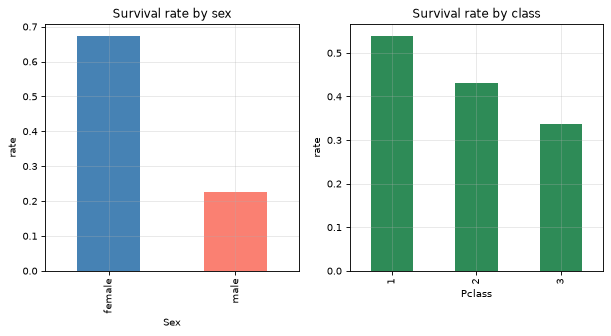

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
df.groupby("Sex")["Survived"].mean().plot.bar(ax=axes[0], color=["steelblue", "salmon"])
axes[0].set_title("Survival rate by sex"); axes[0].set_ylabel("rate")
df.groupby("Pclass")["Survived"].mean().plot.bar(ax=axes[1], color="seagreen")
axes[1].set_title("Survival rate by class"); axes[1].set_ylabel("rate")
print(df.groupby("Sex")["Survived"].agg(["mean", "count"]).round(3).to_string())
print(df.groupby("Pclass")["Survived"].agg(["mean", "count"]).round(3).to_string())


## Age distribution by survival

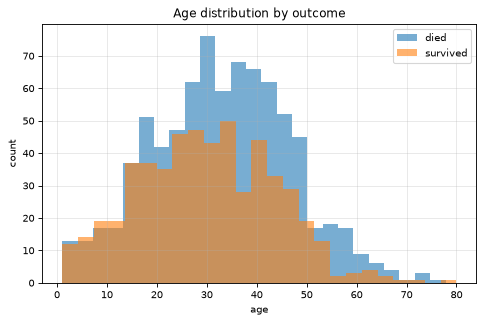

In [ ]:

fig, ax = plt.subplots()
ax.hist(df.query("Survived == 0")["Age"].dropna(), bins=25, alpha=0.6, label="died")
ax.hist(df.query("Survived == 1")["Age"].dropna(), bins=25, alpha=0.6, label="survived")
ax.set_xlabel("age"); ax.set_ylabel("count"); ax.legend()
ax.set_title("Age distribution by outcome")


## Fare vs survival

median fare — died: 11.0 | survived: 12.5


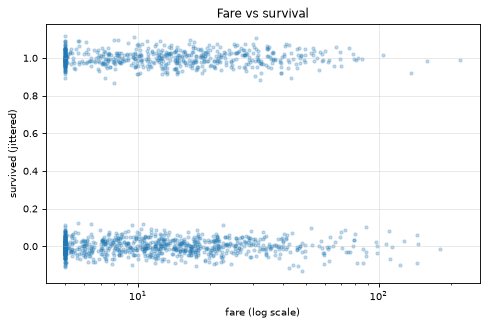

In [ ]:

fig, ax = plt.subplots()
ax.scatter(df["Fare"], df["Survived"] + np.random.RandomState(SEED).normal(0, 0.04, len(df)),
           alpha=0.25, s=8)
ax.set_xscale("log"); ax.set_xlabel("fare (log scale)"); ax.set_ylabel("survived (jittered)")
ax.set_title("Fare vs survival")
print("median fare — died: %.1f | survived: %.1f" % (
    df.query("Survived == 0")["Fare"].median(), df.query("Survived == 1")["Fare"].median()))


## Takeaways

- Women and 1st-class passengers dominate survival — matches history.
- Fare has a long tail; log scale is the right view.
- Age signal is weak alone; might help in interaction with class.